### read file

In [2]:
# read file

def read_file(filename):
    with open(filename, 'r') as file:
        content = file.read()
    return content

text = read_file('task1.txt')
print(text)

def print_line_separator(num=19):
    print('-' * num)

Subject: Team Meeting Reminder

Hello Team,

This is a reminder about the upcoming team meeting scheduled for next Monday at 10:00 AM in Conference Room A. Please review the project documentation before the meeting. You can find the files here: project_docs_v3.pdf.

Agenda:
1. Project progress updates.
2. Discussion on upcoming deadlines.
3. Q&A session.

If you have any questions, feel free to reach out to the project manager at manager@example.com or the assistant at assistant@example.org.

Best regards,  
John Doe  
Team Lead  
john.doe@example.com



### text cleaning and regex
##### Remove punctuations

In [3]:
print(text[-30:])
import string

# Remove digits
clean_digits = text.translate(str.maketrans('', '', string.digits))

print_line_separator()

# Remove punctuation
clean_punctuation = text.translate(str.maketrans('', '', string.punctuation))
# print(clean_punctuation)

# if '@' not in text:
#     print("No @ in text — you'll need to normalize obfuscated emails or extract before cleaning.")
# else:
#     print("Found @ — preserving it during translate will help keep emails intact.")

print('@ in text -> ', '@' in text)

print_line_separator()

# text_for_at = 'This is a test email: test@test.com and bit more @@ signs'

#remove punctuation except @ sign
delete = string.punctuation.replace('@', '')
print('punctuations without @', delete)
clean_except_at = text.translate(str.maketrans('', '', delete))
print('@ in clean_punctuation_except_at -> ', '@' in clean_except_at)
print_line_separator()
print(clean_except_at)


print_line_separator(11)


# slower simpler way
# for char in string.punctuation:
#     text_cleaned = text.replace(char, '')
    
# print(text_cleaned)





m Lead  
john.doe@example.com

-------------------
@ in text ->  True
-------------------
punctuations without @ !"#$%&'()*+,-./:;<=>?[\]^_`{|}~
@ in clean_punctuation_except_at ->  True
-------------------
Subject Team Meeting Reminder

Hello Team

This is a reminder about the upcoming team meeting scheduled for next Monday at 1000 AM in Conference Room A Please review the project documentation before the meeting You can find the files here projectdocsv3pdf

Agenda
1 Project progress updates
2 Discussion on upcoming deadlines
3 QA session

If you have any questions feel free to reach out to the project manager at manager@examplecom or the assistant at assistant@exampleorg

Best regards  
John Doe  
Team Lead  
johndoe@examplecom

-----------


##### 2.2 convert to lower case

In [4]:
text_lower_case = clean_punctuation.lower()
print (text_lower_case)

subject team meeting reminder

hello team

this is a reminder about the upcoming team meeting scheduled for next monday at 1000 am in conference room a please review the project documentation before the meeting you can find the files here projectdocsv3pdf

agenda
1 project progress updates
2 discussion on upcoming deadlines
3 qa session

if you have any questions feel free to reach out to the project manager at managerexamplecom or the assistant at assistantexampleorg

best regards  
john doe  
team lead  
johndoeexamplecom



##### 2.3 Extract emails with regex

In [5]:
print(clean_except_at)

import re
# Extract emails with regex
email_pattern = r'[\w\.]+@[\w\.]+'

emails = re.findall(email_pattern, clean_except_at)
print('Emails:', emails)

Subject Team Meeting Reminder

Hello Team

This is a reminder about the upcoming team meeting scheduled for next Monday at 1000 AM in Conference Room A Please review the project documentation before the meeting You can find the files here projectdocsv3pdf

Agenda
1 Project progress updates
2 Discussion on upcoming deadlines
3 QA session

If you have any questions feel free to reach out to the project manager at manager@examplecom or the assistant at assistant@exampleorg

Best regards  
John Doe  
Team Lead  
johndoe@examplecom

Emails: ['manager@examplecom', 'assistant@exampleorg', 'johndoe@examplecom']


##### regex recap

In [6]:
re_text = "Order #12345 costs $99.99"

# find all digits
digits = re.findall(r'\d+', re_text)
print('Digits found:', digits)

# find all non digits
non_digits = re.findall(r'\D+', re_text)
print('Non-digits found:', non_digits)

# find word characters
words = re.findall(r'\w+', re_text)
print('Words found:', words)

Digits found: ['12345', '99', '99']
Non-digits found: ['Order #', ' costs $', '.']
Words found: ['Order', '12345', 'costs', '99', '99']


##### Cleaning text as a function

In [7]:
def clean_text(text):
    # remove punctuation,. lowercase, extract emails
    import string
   
#    find emails
    emails = re.findall(r'[\w\.]+@[\w\.]+', text)
   
    # Remove punctuation
    text_clean = text.translate(str.maketrans('', '', string.punctuation))
    
    # Convert to lower case
    text_clean_lower = text_clean.lower()
    
    return text_clean_lower, emails

clean_text_funct = clean_text(text)

# print(clean_text_funct)

claned_text, emails_found = clean_text_funct
print_line_separator()
print('Cleaned Text:', claned_text)
print('Emails Found:', emails_found)

    

-------------------
Cleaned Text: subject team meeting reminder

hello team

this is a reminder about the upcoming team meeting scheduled for next monday at 1000 am in conference room a please review the project documentation before the meeting you can find the files here projectdocsv3pdf

agenda
1 project progress updates
2 discussion on upcoming deadlines
3 qa session

if you have any questions feel free to reach out to the project manager at managerexamplecom or the assistant at assistantexampleorg

best regards  
john doe  
team lead  
johndoeexamplecom

Emails Found: ['manager@example.com', 'assistant@example.org.', 'john.doe@example.com']


##### Tokenization and frequency

In [8]:
import nltk
# nltk.download('punkt_tab')

# Attempt to tokenize using NLTK; if required data is missing, download it and retry.
try:
    tokens = nltk.tokenize.word_tokenize(claned_text)
    snetence_tokens = nltk.tokenize.sent_tokenize(claned_text)
except LookupError as e:
    print(e)
    print_line_separator()
    # Common missing resource: 'punkt' for tokenizers/punkt
    print('NLTK resource missing:', e)
    print("Downloading NLTK 'punkt' tokenizer data...")
    nltk.download('punkt')
    tokens = nltk.tokenize.word_tokenize(claned_text)

print('Tokens:', tokens)
print('Tokens:', len(tokens))
print(snetence_tokens)

Tokens: ['subject', 'team', 'meeting', 'reminder', 'hello', 'team', 'this', 'is', 'a', 'reminder', 'about', 'the', 'upcoming', 'team', 'meeting', 'scheduled', 'for', 'next', 'monday', 'at', '1000', 'am', 'in', 'conference', 'room', 'a', 'please', 'review', 'the', 'project', 'documentation', 'before', 'the', 'meeting', 'you', 'can', 'find', 'the', 'files', 'here', 'projectdocsv3pdf', 'agenda', '1', 'project', 'progress', 'updates', '2', 'discussion', 'on', 'upcoming', 'deadlines', '3', 'qa', 'session', 'if', 'you', 'have', 'any', 'questions', 'feel', 'free', 'to', 'reach', 'out', 'to', 'the', 'project', 'manager', 'at', 'managerexamplecom', 'or', 'the', 'assistant', 'at', 'assistantexampleorg', 'best', 'regards', 'john', 'doe', 'team', 'lead', 'johndoeexamplecom']
Tokens: 82
['subject team meeting reminder\n\nhello team\n\nthis is a reminder about the upcoming team meeting scheduled for next monday at 1000 am in conference room a please review the project documentation before the meetin

##### Clean tokenization

In [9]:
# keep only alphabetic tokens
alpha_tokens=[token for token in tokens if token.isalpha()]
print('Alphabetic Tokens size:', len(alpha_tokens) )

Alphabetic Tokens size: 77


##### Differences between `tokens` and `alpha_tokens`

In [10]:
try:
    # tokens: original token list
    # alpha_tokens: tokens filtered to only alphabetic strings
    removed_positions = [i for i, t in enumerate(tokens) if not t.isalpha()]
    removed_tokens = [tokens[i] for i in removed_positions]
    from collections import Counter
    removed_counts = Counter(removed_tokens)

    print('Total tokens:', len(tokens))
    print('Alphabetic tokens:', len(alpha_tokens))
    print('Removed tokens (count):', len(removed_tokens))
    print('First 30 removed tokens sample:', removed_tokens[:30])
    print('')
    print('Top removed token types:')
    for tok, cnt in removed_counts.most_common(10):
        print(f'  {tok!r}: {cnt}')

    # positional diffs (index -> token)
    pos_diff = list(zip(removed_positions, removed_tokens))
    print('')
    print('Sample positional diffs (index, token):', pos_diff[:30])

    # positions of alpha tokens in the original token list
    alpha_positions = [i for i, t in enumerate(tokens) if t.isalpha()]
    print('')
    print('Alpha token positions sample:', alpha_positions[:30])
except NameError as e:
    print('NameError:', e)
    print('Make sure the tokenization cell was run and `tokens` and `alpha_tokens` exist.')

Total tokens: 82
Alphabetic tokens: 77
Removed tokens (count): 5
First 30 removed tokens sample: ['1000', 'projectdocsv3pdf', '1', '2', '3']

Top removed token types:
  '1000': 1
  'projectdocsv3pdf': 1
  '1': 1
  '2': 1
  '3': 1

Sample positional diffs (index, token): [(20, '1000'), (40, 'projectdocsv3pdf'), (42, '1'), (46, '2'), (51, '3')]

Alpha token positions sample: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


##### Count workd frequency - FreqDist

Top 10 most common words: [('the', 6), ('team', 4), ('meeting', 3), ('at', 3), ('project', 3), ('reminder', 2), ('a', 2), ('upcoming', 2), ('you', 2), ('to', 2)]
6
77


<Axes: xlabel='Samples', ylabel='Counts'>

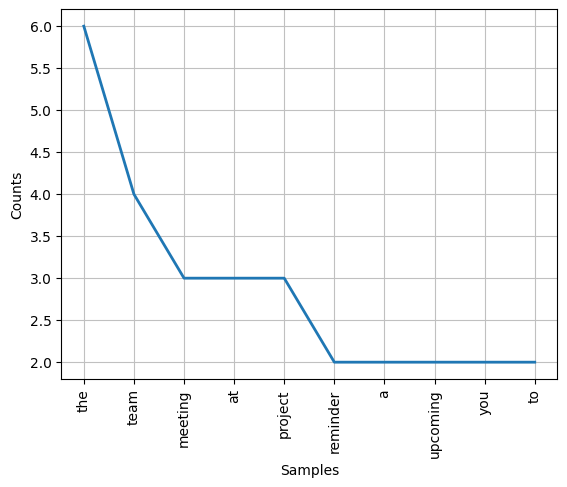

In [11]:
from nltk import FreqDist
import matplotlib.pyplot as plot

fdist = FreqDist(alpha_tokens)

top_10 = fdist.most_common(10)
print('Top 10 most common words:', top_10)

print(fdist['the'])  # Frequency of the word 'the'
print(fdist.N())    # Total number of tokens

fdist.plot(10, cumulative=False)

##### 3.4 Conditional Frequency Distribution

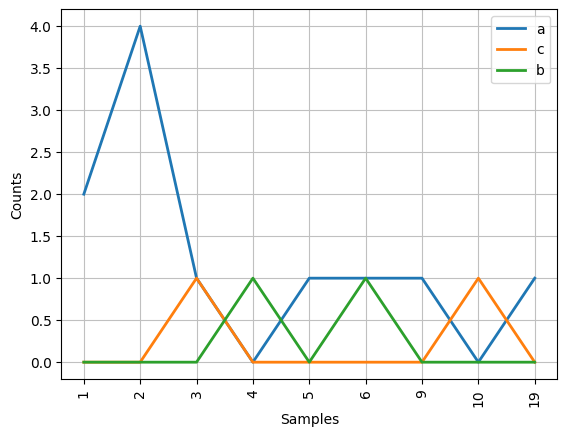

In [12]:
cfd = nltk.ConditionalFreqDist(
    (word[0], len(word))
    for word in alpha_tokens if word[0] in 'abc'
)

# print CFD datacfd.plot()
cfd.plot()
plot.show()


##### 3.4. CFD detailed

CFD pairs condition with event, and based on that counts distibution 

['subject', 'team', 'meeting', 'reminder', 'hello', 'team', 'this', 'is', 'a', 'reminder', 'about', 'the', 'upcoming', 'team', 'meeting', 'scheduled', 'for', 'next', 'monday', 'at', 'am', 'in', 'conference', 'room', 'a', 'please', 'review', 'the', 'project', 'documentation', 'before', 'the', 'meeting', 'you', 'can', 'find', 'the', 'files', 'here', 'agenda', 'project', 'progress', 'updates', 'discussion', 'on', 'upcoming', 'deadlines', 'qa', 'session', 'if']
77
[('a', 1), ('a', 5), ('a', 2), ('a', 2), ('c', 10), ('a', 1), ('b', 6), ('c', 3), ('a', 6), ('a', 3), ('a', 2), ('a', 9), ('a', 2), ('a', 19), ('b', 4)]


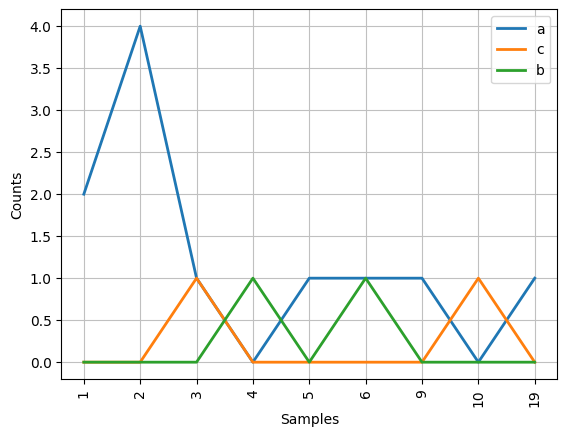

In [36]:
condition = [(char, len(word)) 
             for word in alpha_tokens
             for char in [word[0]] if char in ['a', 'b', 'c']]
print(alpha_tokens[:50])
print(len(alpha_tokens))

print(condition)
cfdc = nltk.ConditionalFreqDist(condition)
cfdc.plot()
plot.show()

##### 4.1 Gutenberg Corpus - Find Most Common Word

In [93]:
from nltk.corpus import gutenberg
from nltk import FreqDist
nltk.download('gutenberg')



def most_common_word_in_gutenberg():
    # get all words from Gutenberg corpus
    all_words = gutenberg.words()

    # filter to alphabetic words and convert to lowercase
    words = [word.lower() for word in all_words if word.isalpha()]

    # print(words[:50])

    # compute frequency distribution
    fdist = FreqDist(words) 
    
    # get top 10 most common words
    fdist_top_10  = fdist.most_common(10)
    
    word, count = fdist_top_10[0]

    return word, count



def most_n_common_words_in_gutenberg(num_of_words=10):
    # get all words from Gutenberg corpus
    all_words = gutenberg.words()

    # filter to alphabetic words and convert to lowercase
    words = [word.lower() for word in all_words if word.isalpha()]

    # print(words[:50])

    # compute frequency distribution
    fdist = FreqDist(words) 
    
    # get top 10 most common words
    return fdist.most_common(num_of_words)

gutenberg_word = most_common_word_in_gutenberg()
gutenberg_10_words = most_n_common_words_in_gutenberg(30)


print('Top most common words in Gutenberg corpus:', gutenberg_word )
print('Top 10 most common words in Gutenberg corpus:', gutenberg_10_words)

[nltk_data] Downloading package gutenberg to /home/amar/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


Top most common words in Gutenberg corpus: ('the', 133583)
Top 10 most common words in Gutenberg corpus: [('the', 133583), ('and', 95442), ('of', 71267), ('to', 48057), ('a', 33960), ('in', 33580), ('i', 30265), ('that', 28798), ('he', 25857), ('it', 22303), ('his', 21402), ('for', 19527), ('was', 18715), ('with', 17599), ('not', 17373), ('is', 16435), ('you', 16398), ('be', 16115), ('as', 14528), ('but', 13944), ('all', 13725), ('they', 13104), ('him', 13012), ('shall', 11682), ('her', 11552), ('my', 10511), ('had', 10317), ('them', 10245), ('have', 10116), ('s', 9896)]


##### 4.2 WordNet - Find Synonyms and Antonyms

In [88]:
from nltk.corpus import wordnet
nltk.download('wordnet')

synonims = []
antonyms = []
for syn in wordnet.synsets("happy"):
    # print('Sinset:', syn)
    # print('Definition:', syn.definition())
    # print('Lemmas:', syn.lemmas())
    
    # print('-'*19)
    
    for lemma in syn.lemmas():
        # print('Lemma antonyms :::::', lemma.antonyms())
        synonims.append(lemma.name())
        
        for ant in lemma.antonyms():
            antonyms.append(ant.name())
        
        
        
print('Synonyms of happy:::', set(synonims))   
print('Antonyms of happy:::', set(antonyms))     

print(most_common_word_in_gutenberg())


def common_word_relationships(word): 
    """ Find the most common word in the Gutenberg corpus, 
    and determine its synonyms and antonyms using WordNet. """ 
    
    # Your code here 
    word, count = word
    
    synonims = []
    antonyms = []
    for syn in wordnet.synsets(word):
        # print('Sinset:', syn)
        # print('Definition:', syn.definition())
        # print('Lemmas:', syn.lemmas())
        
        # print('-'*19)
        
        for lemma in syn.lemmas():
            # print('Lemma antonyms :::::', lemma.antonyms())
            synonims.append(lemma.name())
            
            for ant in lemma.antonyms():
                antonyms.append(ant.name())
        
        
            
    # print('Synonyms of happy:::', set(synonims))   
    # print('Antonyms of happy:::', set(antonyms))     

     
    return word, count, synonims, antonyms


[nltk_data] Downloading package wordnet to /home/amar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Synonyms of happy::: {'felicitous', 'well-chosen', 'happy', 'glad'}
Antonyms of happy::: {'unhappy'}
('the', 133583)


In [100]:
gutenberg_10_words[-2]

print(common_word_relationships(gutenberg_word))
print(common_word_relationships(gutenberg_10_words[15]))

('the', 133583, [], [])
('is', 16435, ['be', 'be', 'be', 'exist', 'be', 'be', 'equal', 'be', 'constitute', 'represent', 'make_up', 'comprise', 'be', 'be', 'follow', 'embody', 'be', 'personify', 'be', 'be', 'live', 'be', 'cost', 'be'], ['differ'])


##### 5.3 Brown Corpus with Universal Tagset

In [108]:
from nltk.corpus import brown
nltk.download('brown')
nltk.download('universal_tagset')

tagged_sentences = brown.tagged_sents(tagset='universal')
print('Total snetences ', len(tagged_sentences))

# first snetence
print("First sentence", tagged_sentences[0])

[nltk_data] Downloading package brown to /home/amar/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /home/amar/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


Total snetences  57340
First sentence [('The', 'DET'), ('Fulton', 'NOUN'), ('County', 'NOUN'), ('Grand', 'ADJ'), ('Jury', 'NOUN'), ('said', 'VERB'), ('Friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP'), ("Atlanta's", 'NOUN'), ('recent', 'ADJ'), ('primary', 'NOUN'), ('election', 'NOUN'), ('produced', 'VERB'), ('``', '.'), ('no', 'DET'), ('evidence', 'NOUN'), ("''", '.'), ('that', 'ADP'), ('any', 'DET'), ('irregularities', 'NOUN'), ('took', 'VERB'), ('place', 'NOUN'), ('.', '.')]


##### 5.4 Train a Bigram Tagger 

##### split into train/test

In [131]:
train_size = int(len(tagged_sentences) * 0.9)
train_sents = tagged_sentences[:train_size]
test_sents = tagged_sentences[train_size:]



##### Step 3: Build tagger chain (backoff pattern)
##### If BigramTagger fails → try UnigramTagger → try DefaultTagger

In [117]:
from nltk import DefaultTagger, UnigramTagger, BigramTagger

t0 = DefaultTagger('NOUN')
t1 = UnigramTagger(train_sents, backoff=t0)
t2 = BigramTagger(train_sents, backoff=t1)

print('BigramTagger trained !!!')

BigramTagger trained !!!


In [128]:
sentence = "The quick brown fox jumps over the lazy dog."
tokens = nltk.tokenize.word_tokenize(sentence)

print(tokens)

tagged_sentence = t2.tag(tokens)
print(tagged_sentence)

['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '.']
[('The', 'DET'), ('quick', 'ADJ'), ('brown', 'ADJ'), ('fox', 'NOUN'), ('jumps', 'VERB'), ('over', 'ADP'), ('the', 'DET'), ('lazy', 'ADJ'), ('dog', 'NOUN'), ('.', '.')]


##### 5.6 Calculate Accuracy

In [134]:
accuracy = t2.accuracy(test_sents)
print(f"Tagger Accuracy: {accuracy:.4f}")


Tagger Accuracy: 0.9485


In [135]:
def categorize_and_tag_brown_corpus(sentence): 
    """ Train a Bigram tagger, 
    tag a given sentence, 
    and evaluate accuracy. """ 
    
    # Your code here 
    
    # prepare data
    tagged_sentences = brown.tagged_sents(tagset='universal')
    
    train_size = int(len(tagged_sentences) * 0.9)
    train_sents = tagged_sentences[:train_size]
    test_sents = tagged_sentences[train_size:]
    
    # train tagger chain
    t0 = DefaultTagger('NOUN')
    t1 = UnigramTagger(train_sents, backoff=t0)
    t2 = BigramTagger(train_sents, backoff=t1)
    
    # tag target sentence
    tokens = nltk.tokenize.word_tokenize(sentence)
    tagged_sentence = t2.tag(tokens)
    
    # calculate accuracy
    accuracy = t2.accuracy(test_sents)
    
     
    return tagged_sentence, accuracy

In [136]:
categorize_and_tag_brown_corpus(sentence)

([('The', 'DET'),
  ('quick', 'ADJ'),
  ('brown', 'ADJ'),
  ('fox', 'NOUN'),
  ('jumps', 'VERB'),
  ('over', 'ADP'),
  ('the', 'DET'),
  ('lazy', 'ADJ'),
  ('dog', 'NOUN'),
  ('.', '.')],
 0.9485446658703716)